In [ ]:
#!/usr/bin/env python
# coding: utf-8

In [13]:
import os
import sys
import time
import warnings
import openml
import socket
import concurrent.futures

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from ucimlrepo import fetch_ucirepo
from pymfe.mfe import MFE
from sklearn.datasets import fetch_openml
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_val_score, StratifiedKFold, KFold, LeaveOneOut
from sklearn.tree import DecisionTreeClassifier
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OrdinalEncoder, LabelEncoder, StandardScaler
from sklearn.model_selection import cross_validate
from sklearn.utils import resample
from sklearn.utils.multiclass import type_of_target

# --- Configurações Globais ---
os.environ["PYTHONWARNINGS"] = "ignore"
warnings.simplefilter(action='ignore', category=FutureWarning)
warnings.simplefilter(action='ignore', category=UserWarning)
warnings.filterwarnings('ignore')


openml.config.apikey = "a53d4175d64b1ba34ce0bc8a63ee6ec8"

# Lock para gravação segura do CSV
print("✅ Imports carregados e ambiente configurado!")

✅ Imports carregados e ambiente configurado!


In [16]:
arquivo_log = "checkpoint_meta_base.csv"

# Lista inicial de IDs do UCI (Vamos expandir isso depois)
datasets_ids = list(range(1, 451)) + [
    451, 458, 468, 469, 472, 476, 477, 485, 492, 493, 502, 504, 514, 519, 528, 529, 
    531, 536, 544, 545, 555, 560, 563, 571, 579, 591, 597, 601, 602, 603, 608, 
    622, 649, 683, 697, 713, 738, 754, 776, 797, 831, 848, 850, 866, 878, 879, 
    880, 887, 891, 901, 902, 915, 925, 936, 942, 
    1000, 1002, 1004, 1008, 1011, 1013, 1015, 1018, 1020, 1022, 1030, 1044, 
    1046, 1050, 1053, 1055, 1060, 1070, 1075, 1080, 1090, 1095,
    1100, 1101, 1104, 1106, 1111, 1115, 1120, 1130, 1140, 1160, 1200, 1250, 1300, 1400, 1500
]

print(f"📊 Total listado manualmente para o UCI: {len(datasets_ids)} datasets.")
print("--- INICIANDO PROCESSAMENTO VIA UCI (COM CHECKPOINT) ---\n")

# Modelos base e MFE
modelos_base = {
    'RF': RandomForestClassifier(n_estimators=50, random_state=42, n_jobs=-1), 
    'SVM': SVC(random_state=42, max_iter=500, tol=1e-2), 
    'kNN': KNeighborsClassifier(n_jobs=-1),
    'LR': LogisticRegression(random_state=42, max_iter=200, solver='saga', tol=1e-2, n_jobs=-1),
    'NB': GaussianNB(),
    'DT': DecisionTreeClassifier(random_state=42)
}
cv_base = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

mfe = MFE(
    groups=["general", "statistical", "info-theory", "landmarking", "model-based", "complexity"],
    summary=["mean", "sd", "min", "max", "skewness", "kurtosis", "median", "iq_range"]
)

def processar_dataset(ds_id):
    dataset = fetch_ucirepo(id=ds_id)
    
    if dataset.data.targets is None:
        return f"ID {ds_id:<5} | {dataset.metadata.name[:15]:<15} | ⚠️ Pulado (Sem target definido)"
        
    X = dataset.data.features.copy()
    y = dataset.data.targets.copy()
    
    if isinstance(y, pd.DataFrame): 
        y = y.squeeze()
        
    # Tolerância bem mais alta para aproveitar a subamostragem
    if X.shape[0] > 100000 or X.shape[1] > 500:
        return f"ID {ds_id:<5} | {dataset.metadata.name[:15]:<15} | ⚠️ Pulado (Gigante: {X.shape})"

    X = X.dropna(axis=1, how='all')
    str_cols = X.select_dtypes(include=['object', 'string', 'category']).columns
    if len(str_cols) > 0:
        X[str_cols] = X[str_cols].astype(str).replace({'<NA>': np.nan, 'nan': np.nan})
        
    if pd.api.types.is_string_dtype(y) or pd.api.types.is_object_dtype(y):
        y = LabelEncoder().fit_transform(y)

    num_cols = X.select_dtypes(include=['int', 'float', 'number']).columns.tolist()
    cat_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()

    preprocessor = ColumnTransformer(transformers=[
        ('num', Pipeline(steps=[('imputer', SimpleImputer(strategy='mean')), ('scaler', StandardScaler())]), num_cols),
        ('cat', Pipeline(steps=[('imputer', SimpleImputer(strategy='most_frequent')), ('encoder', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1))]), cat_cols)
    ])

    TAMANHO_MAXIMO = 2000 
    if X.shape[0] > TAMANHO_MAXIMO:
        X_eval, y_eval = resample(X, y, n_samples=TAMANHO_MAXIMO, random_state=42, stratify=y)
    else:
        X_eval, y_eval = X, y

    best_acc, best_model = -1, None
    for nome_modelo, modelo in modelos_base.items():
        pipeline_avaliacao = Pipeline(steps=[('preprocessor', preprocessor), ('classifier', modelo)])
        acc = np.mean(cross_val_score(pipeline_avaliacao, X_eval, y_eval, cv=cv_base, scoring='accuracy', n_jobs=-1))
        if acc > best_acc:
            best_acc, best_model = acc, nome_modelo

    X_mfe = preprocessor.fit_transform(X_eval) 
    mfe.fit(X_mfe, y_eval.to_numpy() if isinstance(y_eval, pd.Series) else y_eval) 
    ft_names, ft_values = mfe.extract()

    row = dict(zip(ft_names, ft_values))
    row['Dataset_ID'] = ds_id
    row['Dataset_Name'] = dataset.metadata.name
    row['MetaTarget'] = best_model
    
    arquivo_existe = os.path.exists(arquivo_log)
    cols = ['Dataset_ID', 'Dataset_Name', 'MetaTarget'] + ft_names
    pd.DataFrame([row], columns=cols).to_csv(arquivo_log, index=False, mode='a' if arquivo_existe else 'w', header=not arquivo_existe)

    return f"ID {ds_id:<5} | {dataset.metadata.name[:15]:<15} | Vencedor: {best_model:<4} | ✅ {len(ft_names)} features extraídas"


# ==========================================
# 3. LOOP PRINCIPAL COM TIMEOUT
# ==========================================
for ds_id in datasets_ids:
    
    # Checa o cache primeiro para não perder tempo
    if os.path.exists(arquivo_log):
        df_existente = pd.read_csv(arquivo_log, usecols=['Dataset_ID', 'Dataset_Name', 'MetaTarget'])
        if ds_id in df_existente['Dataset_ID'].values:
            nome_cache = df_existente.loc[df_existente['Dataset_ID'] == ds_id, 'Dataset_Name'].iloc[0]
            alvo_cache = df_existente.loc[df_existente['Dataset_ID'] == ds_id, 'MetaTarget'].iloc[0]
            print(f"ID {ds_id:<5} | {nome_cache[:15]:<15} | Vencedor: {alvo_cache:<4} | ⏭️ (Puxado do Cache)")
            continue

    # Executa a função com o limite de 5 minutos (300 segundos)
    try:
        with concurrent.futures.ThreadPoolExecutor(max_workers=1) as executor:
            futuro = executor.submit(processar_dataset, ds_id)
            # O "If" implícito: Se passar de 300 segundos, ele joga o erro e pula pro except
            resultado = futuro.result(timeout=300)
            print(resultado)
            
    except concurrent.futures.TimeoutError:
        print(f"ID {ds_id:<5} | ⏳ Timeout! Passou de 5 minutos. Pulando para o próximo...")
    except Exception as e:
        print(f"ID {ds_id:<5} | ❌ Erro: {str(e)[:60]}...")


# ==========================================
# 4. CARREGAMENTO FINAL PARA A PRÓXIMA CÉLULA
# ==========================================
print("\n--- FINALIZANDO ---")
if os.path.exists(arquivo_log):
    # Carrega a base salva para a variável df_meta
    df_meta = pd.read_csv(arquivo_log)
    
    # Limpeza final de NAs e Infinitos gerados pelo PyMFE
    df_meta.replace([np.inf, -np.inf], np.nan, inplace=True)
    
    # Dropa colunas que têm mais de 20% de valores nulos
    limite = int(0.8 * len(df_meta))
    df_meta = df_meta.dropna(axis=1, thresh=limite)
    
    # Preenche o resto dos nulos com a mediana da coluna
    num_cols = df_meta.select_dtypes(include=[np.number]).columns.drop('Dataset_ID', errors='ignore')
    if len(num_cols) > 0:
        df_meta[num_cols] = SimpleImputer(strategy='median').fit_transform(df_meta[num_cols])

    print(f"🎉 Extração concluída! A variável 'df_meta' está pronta para uso.")
    print(f"   Shape atual: {df_meta.shape[0]} instâncias x {df_meta.shape[1]} atributos.")
else:
    print("Nenhum dataset foi processado.")

📊 Total listado manualmente para o UCI: 542 datasets.
--- INICIANDO PROCESSAMENTO VIA UCI (COM CHECKPOINT) ---

ID 1     | Abalone         | Vencedor: RF   | ⏭️ (Puxado do Cache)
ID 2     | Adult           | Vencedor: LR   | ⏭️ (Puxado do Cache)
ID 3     | Annealing       | Vencedor: RF   | ⏭️ (Puxado do Cache)
ID 4     | ❌ Erro: "Anonymous Microsoft Web Data" dataset (id=4) exists in the ...
ID 5     | ❌ Erro: "Arrhythmia" dataset (id=5) exists in the repository, but is...
ID 6     | ❌ Erro: "Artificial Characters" dataset (id=6) exists in the reposit...
ID 7     | ❌ Erro: "Audiology (Original)" dataset (id=7) exists in the reposito...
ID 8     | Audiology (Stan | Vencedor: RF   | ⏭️ (Puxado do Cache)
ID 9     | ❌ Erro: Supported target types are: ('binary', 'multiclass'). Got 'c...
ID 10    | Automobile      | Vencedor: RF   | ⏭️ (Puxado do Cache)
ID 11    | ❌ Erro: "Badges" dataset (id=11) exists in the repository, but is no...
ID 12    | Balance Scale   | Vencedor: SVM  | ⏭️ (Puxad

In [17]:
arquivo_log = "checkpoint_meta_base.csv"

print(f"📥 Carregando meta-base salva de '{arquivo_log}'...")
df_meta = pd.read_csv(arquivo_log)

# Limpeza de segurança final (Garantir que não há NaNs ou Infs que o PyMFE deixou passar)
df_meta.replace([np.inf, -np.inf], np.nan, inplace=True)
limite = int(0.8 * len(df_meta))
df_meta = df_meta.dropna(axis=1, thresh=limite)
num_cols = df_meta.select_dtypes(include=[np.number]).columns.drop('Dataset_ID', errors='ignore')
if len(num_cols) > 0:
    df_meta[num_cols] = SimpleImputer(strategy='median').fit_transform(df_meta[num_cols])

print(f"📊 Meta-base pronta: {df_meta.shape[0]} instâncias x {df_meta.shape[1]} atributos.")

📥 Carregando meta-base salva de 'checkpoint_meta_base.csv'...
📊 Meta-base pronta: 112 instâncias x 416 atributos.


In [18]:
class MetaFeaturePruner:
    def v1_brute_force(self, X):
        return np.arange(X.shape[1]), 0.0

    def v2_hard_pruning(self, X, y):
        start = time.time()
        rf = RandomForestClassifier(n_estimators=50, random_state=42, n_jobs=-1)
        rf.fit(X, y)
        idx = np.where(rf.feature_importances_ > np.mean(rf.feature_importances_))[0]
        return idx, time.time() - start

    def v3_erf(self, X, y):
        start = time.time()
        rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
        rf.fit(X, y)
        idx = np.where(rf.feature_importances_ >= (np.mean(rf.feature_importances_) * 0.5))[0]
        return idx, time.time() - start

class GeneticFeatureSelector:
    def __init__(self, n_generations=50, crossover_prob=0.8, mutation_prob=0.05, random_state=42):
        self.n_generations = n_generations
        self.crossover_prob = crossover_prob
        self.base_mutation_prob = mutation_prob
        self.random_state = random_state
        
        self.evaluator = RandomForestClassifier(n_estimators=20, random_state=self.random_state, n_jobs=-1)
        self.cv_strategy = KFold(n_splits=3, shuffle=True, random_state=self.random_state)
        self.history = []
        self.fitness_cache = {}

    def _calculate_fitness(self, X, y, chromosome):
        chrom_key = chromosome.tobytes()
        if chrom_key in self.fitness_cache:
            return self.fitness_cache[chrom_key]
            
        n_selected = np.sum(chromosome)
        if n_selected == 0: 
            return 1e-4, n_selected
            
        X_subset = X[:, chromosome == 1]
        acc = np.mean(cross_val_score(self.evaluator, X_subset, y, cv=self.cv_strategy, scoring='balanced_accuracy', n_jobs=-1))
        
        sparsity_bonus = 1.0 - (n_selected / X.shape[1])
        fitness = max(1e-4, acc + (0.001 * sparsity_bonus))
        
        self.fitness_cache[chrom_key] = (fitness, n_selected)
        return fitness, n_selected

    def _tournament_selection(self, population, fitness_scores, k=3):
        pop_size = len(population)
        torneios = np.random.randint(0, pop_size, size=(pop_size, k))
        scores_torneios = fitness_scores[torneios]
        vencedores_idx_relativo = np.argmax(scores_torneios, axis=1)
        vencedores_idx_real = torneios[np.arange(pop_size), vencedores_idx_relativo]
        return population[vencedores_idx_real]

    def fit_transform(self, X, y):
        start_time = time.time()
        np.random.seed(self.random_state)
        n_features = X.shape[1]
        
        pop_size = max(20, min(100, n_features // 2))
        prob_1 = min(0.5, 175 / n_features) if n_features > 0 else 0.5
        population = np.random.choice([0, 1], size=(pop_size, n_features), p=[1-prob_1, prob_1])

        best_global_chromosome = None
        best_global_fitness = -1
        best_global_count = 0

        print(f"        [GA] Iniciando evolução... População: {pop_size} | Gerações: {self.n_generations}")

        for generation in range(self.n_generations):
            fitness_results = [self._calculate_fitness(X, y, ind) for ind in population]
            fitness_scores = np.array([f[0] for f in fitness_results])
            counts = np.array([f[1] for f in fitness_results])
            
            best_idx = np.argmax(fitness_scores)
            
            if fitness_scores[best_idx] > best_global_fitness:
                best_global_fitness = fitness_scores[best_idx]
                best_global_count = counts[best_idx]
                best_global_chromosome = population[best_idx].copy()

            self.history.append({
                'generation': generation,
                'best_fitness': best_global_fitness,
                'num_features': best_global_count
            })

            diversidade = np.mean(np.var(population, axis=0))
            if generation > 20 and diversidade < 0.01: 
                print(f"        [GA] Parada antecipada: Convergência genética na Geração {generation:03d} (Div: {diversidade:.4f}).")
                break

            if generation > 0 and generation % 10 == 0:
                current_mutation = min(0.3, self.base_mutation_prob * 4)
                print(f"        [GA] Gen {generation:03d}/{self.n_generations} | Melhor: {best_global_fitness:.4f} | Ativas: {best_global_count:03d} | Div: {diversidade:.3f} ⚠️ CAOS")
            else:
                current_mutation = self.base_mutation_prob
                if generation % 10 == 0 or generation == self.n_generations - 1:
                    print(f"        [GA] Gen {generation:03d}/{self.n_generations} | Melhor: {best_global_fitness:.4f} | Ativas: {best_global_count:03d} | Div: {diversidade:.3f}")

            parents = self._tournament_selection(population, fitness_scores, k=3)
            
            next_gen = [best_global_chromosome.copy()]
            
            for i in range(0, pop_size - 1, 2):
                p1 = parents[i]
                p2 = parents[(i+1) % len(parents)] 
                
                if np.random.rand() < self.crossover_prob:
                    mask = np.random.rand(n_features) > 0.5
                    c1 = np.where(mask, p1, p2)
                    c2 = np.where(mask, p2, p1)
                else:
                    c1, c2 = p1.copy(), p2.copy()
                
                c1 ^= (np.random.rand(n_features) < current_mutation)
                c2 ^= (np.random.rand(n_features) < current_mutation)
                
                next_gen.extend([c1, c2])

            population = np.array(next_gen)[:pop_size]

        final_indices = np.where(best_global_chromosome == 1)[0]
        return final_indices, time.time() - start_time, self.history


--- INICIANDO TESTES DOS ESTÁGIOS ---
-> 1/4. Analisando V1 (Nenhuma Poda / Força Bruta)...
        Meta-features retidas: 413

-> 2/4. Aplicando V2 (Hard Pruning Padrão)...
        Meta-features retidas: 167

-> 3/4. Aplicando V3 (Enriched Random Forest)...
        Meta-features retidas: 301

-> 4/4. Aplicando V4 (Otimização via Algoritmo Genético em cima do V3)...
        [GA] Iniciando evolução... População: 100 | Gerações: 300
        [GA] Gen 000/300 | Melhor: 0.3408 | Ativas: 144 | Div: 0.247
        [GA] Gen 010/300 | Melhor: 0.3616 | Ativas: 157 | Div: 0.225 ⚠️ CAOS
        [GA] Gen 020/300 | Melhor: 0.3616 | Ativas: 157 | Div: 0.227 ⚠️ CAOS
        [GA] Gen 030/300 | Melhor: 0.3616 | Ativas: 157 | Div: 0.217 ⚠️ CAOS
        [GA] Gen 040/300 | Melhor: 0.3734 | Ativas: 162 | Div: 0.229 ⚠️ CAOS
        [GA] Gen 050/300 | Melhor: 0.3837 | Ativas: 155 | Div: 0.227 ⚠️ CAOS
        [GA] Gen 060/300 | Melhor: 0.3837 | Ativas: 155 | Div: 0.233 ⚠️ CAOS
        [GA] Gen 070/300 | Melhor

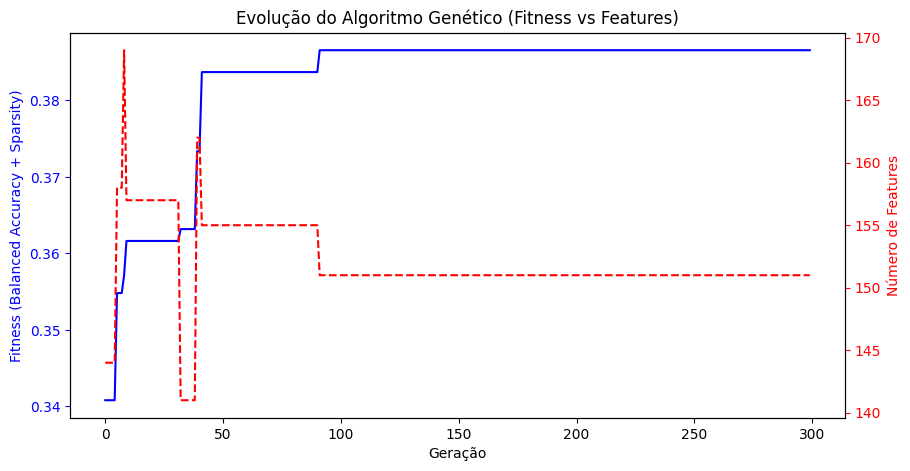

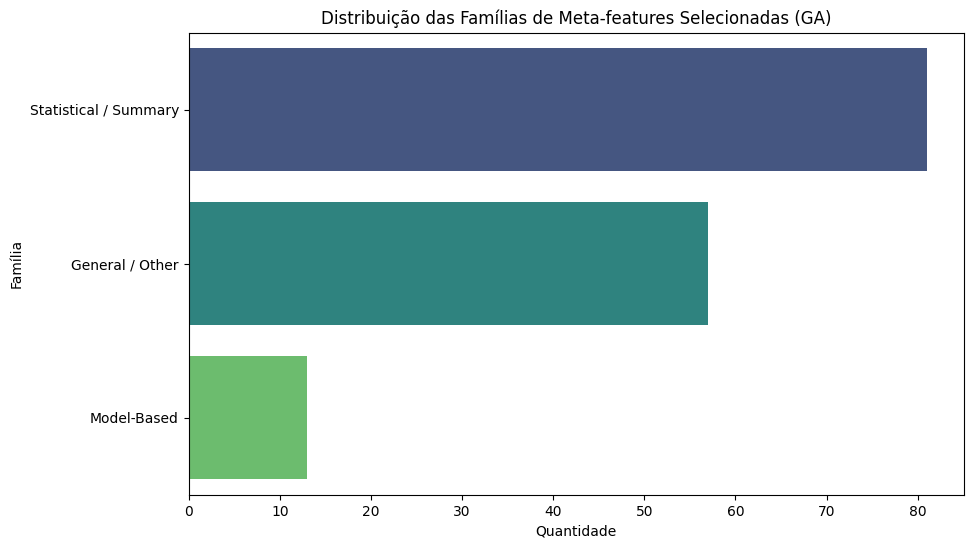


--- Analisando Importância RF vs Seleção GA ---


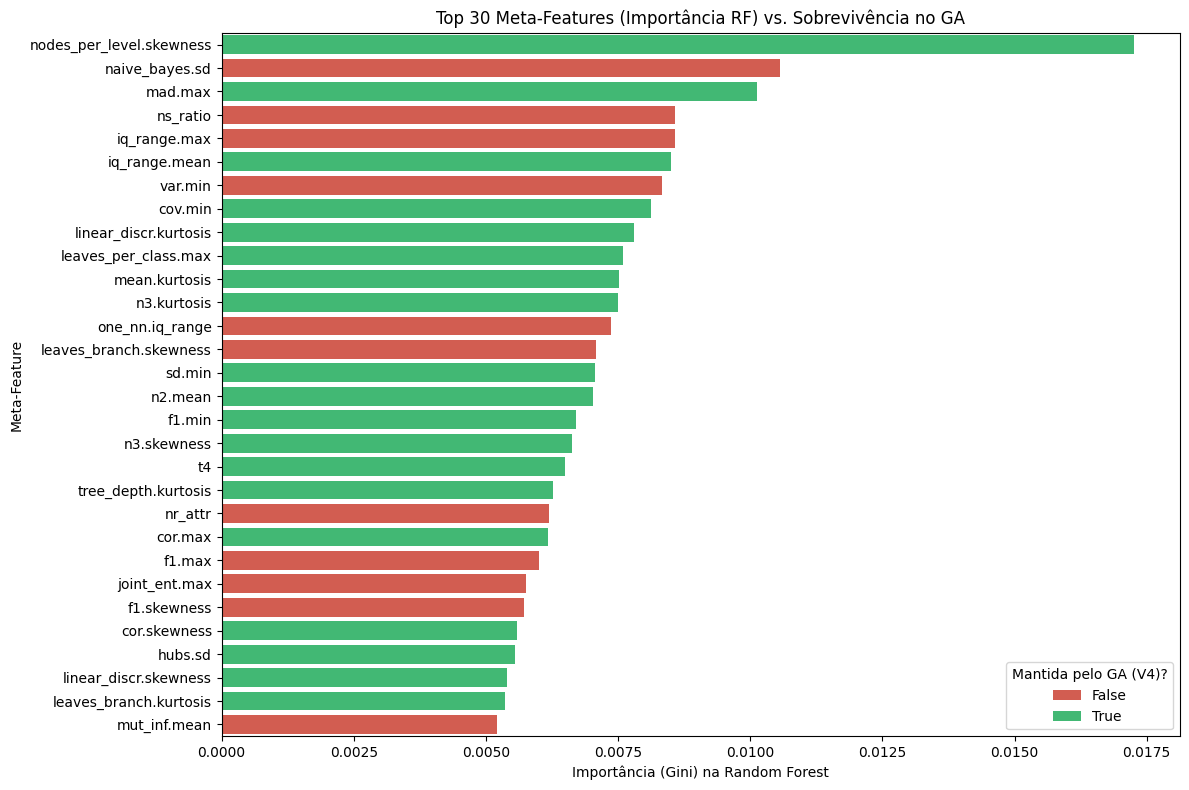


✅ Pipeline 100% finalizado! Verifique a sua pasta raiz para encontrar os 3 gráficos salvos.

=== RESUMO DOS RESULTADOS ===
           Modelo  Qtd_MFs_Sobreviventes  Tempo_Pruning(s)  Tempo_Total(s)  Acc_Balanceada  F1_Macro
 V1 (Força Bruta)                    413            0.0000          0.0000          0.2157    0.1917
V2 (Hard Pruning)                    167            0.0957          0.0957          0.2756    0.2583
         V3 (ERF)                    301            0.1322          0.1322          0.2500    0.2366
    V4 (ERF + GA)                    151            0.1322       1950.6376          0.2396    0.2189


In [19]:
def executar_pipeline_wrapper(df_meta, arq_resultados="resultados_tabela.csv", arq_features="meta_features_v4.csv"):
    
    # Separando Features do Target (ignorando colunas de identificação)
    colunas_ignorar = ['Dataset_ID', 'Dataset_Name', 'MetaTarget']
    X_meta = df_meta.drop(columns=[col for col in colunas_ignorar if col in df_meta.columns]).values
    y_meta = LabelEncoder().fit_transform(df_meta['MetaTarget'])
    meta_cols = df_meta.drop(columns=[col for col in colunas_ignorar if col in df_meta.columns]).columns.tolist()
    
    cv_eval = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    final_clf = RandomForestClassifier(n_estimators=50, random_state=42, n_jobs=-1)
    
    metricas = ['balanced_accuracy', 'f1_macro']
    resultados = []
    pruner = MetaFeaturePruner()
    
    print("\n--- INICIANDO TESTES DOS ESTÁGIOS ---")
    
    # --- V1 ---
    print("-> 1/4. Analisando V1 (Nenhuma Poda / Força Bruta)...")
    idx_v1, t_v1 = pruner.v1_brute_force(X_meta)
    scores_v1 = cross_validate(final_clf, X_meta[:, idx_v1], y_meta, cv=cv_eval, scoring=metricas)
    acc_v1, f1_v1 = np.mean(scores_v1['test_balanced_accuracy']), np.mean(scores_v1['test_f1_macro'])
    print(f"        Meta-features retidas: {len(idx_v1)}\n")
    
    # --- V2 ---
    print("-> 2/4. Aplicando V2 (Hard Pruning Padrão)...")
    idx_v2, t_v2 = pruner.v2_hard_pruning(X_meta, y_meta)
    scores_v2 = cross_validate(final_clf, X_meta[:, idx_v2], y_meta, cv=cv_eval, scoring=metricas)
    acc_v2, f1_v2 = np.mean(scores_v2['test_balanced_accuracy']), np.mean(scores_v2['test_f1_macro'])
    print(f"        Meta-features retidas: {len(idx_v2)}\n")
    
    # --- V3 ---
    print("-> 3/4. Aplicando V3 (Enriched Random Forest)...")
    idx_v3, t_v3 = pruner.v3_erf(X_meta, y_meta)
    scores_v3 = cross_validate(final_clf, X_meta[:, idx_v3], y_meta, cv=cv_eval, scoring=metricas)
    acc_v3, f1_v3 = np.mean(scores_v3['test_balanced_accuracy']), np.mean(scores_v3['test_f1_macro'])
    print(f"        Meta-features retidas: {len(idx_v3)}\n")
    
    # --- V4 ---
    print("-> 4/4. Aplicando V4 (Otimização via Algoritmo Genético em cima do V3)...")
    X_v3 = X_meta[:, idx_v3] 
    ga = GeneticFeatureSelector(n_generations=300, random_state=42)
    idx_ga_relativo, t_ga, ga_history = ga.fit_transform(X_v3, y_meta)
    
    idx_v4_absoluto = idx_v3[idx_ga_relativo]
    scores_v4 = cross_validate(final_clf, X_meta[:, idx_v4_absoluto], y_meta, cv=cv_eval, scoring=metricas)
    acc_v4, f1_v4 = np.mean(scores_v4['test_balanced_accuracy']), np.mean(scores_v4['test_f1_macro'])
    print(f"        Meta-features retidas: {len(idx_v4_absoluto)}\n")
    
    # --- SALVAR O NOME DAS FEATURES VENCEDORAS (V4) EM CSV ---
    features_v4_nomes = [meta_cols[i] for i in idx_v4_absoluto]
    pd.DataFrame({"Meta_Features_Sobreviventes_V4": features_v4_nomes}).to_csv(arq_features, index=False)
    print(f"✅ Nomes das Meta-Features vencedoras salvos em: '{arq_features}'")
    
    # --- MONTAR RELATÓRIO ---
    modelos_info = [
        ('V1 (Força Bruta)', len(idx_v1), t_v1, t_v1, acc_v1, f1_v1),
        ('V2 (Hard Pruning)', len(idx_v2), t_v2, t_v2, acc_v2, f1_v2),
        ('V3 (ERF)', len(idx_v3), t_v3, t_v3, acc_v3, f1_v3),
        ('V4 (ERF + GA)', len(idx_v4_absoluto), t_v3, t_v3 + t_ga, acc_v4, f1_v4)
    ]
    
    for nome, qtd, tp, tt, acc, f1 in modelos_info:
        resultados.append({
            'Modelo': nome, 
            'Qtd_MFs_Sobreviventes': qtd,
            'Tempo_Pruning(s)': round(tp, 4), 
            'Tempo_Total(s)': round(tt, 4),
            'Acc_Balanceada': round(acc, 4),
            'F1_Macro': round(f1, 4)
        })
        
    df_resultados = pd.DataFrame(resultados)
    df_resultados.to_csv(arq_resultados, index=False)
    print(f"✅ Tabela de comparação salva em: '{arq_resultados}'\n")
    
    # =====================================================================
    # 4. GRÁFICOS E ANÁLISE VISUAL
    # =====================================================================
    
    # Gráfico 1: Evolução do GA
    history_df = pd.DataFrame(ga_history)
    fig, ax1 = plt.subplots(figsize=(10, 5))
    ax1.plot(history_df['generation'], history_df['best_fitness'], 'b-')
    ax1.set_xlabel('Geração')
    ax1.set_ylabel('Fitness (Balanced Accuracy + Sparsity)', color='b')
    ax1.tick_params('y', colors='b')
    
    ax2 = ax1.twinx()
    ax2.plot(history_df['generation'], history_df['num_features'], 'r--')
    ax2.set_ylabel('Número de Features', color='r')
    ax2.tick_params('y', colors='r')
    
    plt.title('Evolução do Algoritmo Genético (Fitness vs Features)')
    plt.savefig('grafico_1_evolucao_ga.png', dpi=300, bbox_inches='tight') 
    plt.show()

    # Gráfico 2: Famílias de Meta-Features
    def extrair_grupo(nome):
        if 'mean' in nome or 'sd' in nome or 'min' in nome or 'max' in nome: return 'Statistical / Summary'
        elif 'attrEnt' in nome or 'mutInf' in nome or 'classEnt' in nome or 'jointEnt' in nome: return 'Info-Theory'
        elif 'bestNode' in nome or 'eliteNN' in nome or 'linearDiscr' in nome or 'naiveBayes' in nome or 'oneNN' in nome or 'randomNode' in nome or 'worstNode' in nome: return 'Landmarking'
        elif 'leaves' in nome or 'tree' in nome or 'nodes' in nome or 'varImportance' in nome: return 'Model-Based'
        else: return 'General / Other'

    df_familias = pd.DataFrame({"Nome": features_v4_nomes})
    df_familias['Grupo'] = df_familias['Nome'].apply(extrair_grupo)

    plt.figure(figsize=(10, 6))
    sns.countplot(data=df_familias, y='Grupo', order=df_familias['Grupo'].value_counts().index, palette='viridis')
    plt.title('Distribuição das Famílias de Meta-features Selecionadas (GA)')
    plt.xlabel('Quantidade')
    plt.ylabel('Família')
    plt.savefig('grafico_2_familias_mf.png', dpi=300, bbox_inches='tight')
    plt.show()

    # Gráfico 3: RF vs GA
    print("\n--- Analisando Importância RF vs Seleção GA ---")
    rf_analise = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
    rf_analise.fit(X_meta, y_meta)

    df_importances = pd.DataFrame({
        'Meta_Feature': meta_cols,
        'Importancia_RF': rf_analise.feature_importances_
    })
    df_importances['Mantida_pelo_GA'] = df_importances['Meta_Feature'].isin(features_v4_nomes)
    top_30_rf = df_importances.sort_values(by='Importancia_RF', ascending=False).head(30)

    plt.figure(figsize=(12, 8))
    sns.barplot(
        data=top_30_rf, x='Importancia_RF', y='Meta_Feature', 
        hue='Mantida_pelo_GA', dodge=False, palette={True: '#2ecc71', False: '#e74c3c'}
    )
    plt.title('Top 30 Meta-Features (Importância RF) vs. Sobrevivência no GA')
    plt.xlabel('Importância (Gini) na Random Forest')
    plt.ylabel('Meta-Feature')
    plt.legend(title='Mantida pelo GA (V4)?', loc='lower right')
    plt.tight_layout()
    plt.savefig('grafico_3_rf_vs_ga.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    print("\n✅ Pipeline 100% finalizado! Verifique a sua pasta raiz para encontrar os 3 gráficos salvos.")
    return df_resultados

# =====================================================================
# INICIALIZAÇÃO
# =====================================================================
df_final = executar_pipeline_wrapper(df_meta)
print("\n=== RESUMO DOS RESULTADOS ===")
print(df_final.to_string(index=False))